**Kelompok 4 (3AEC3)**
Anggota:
1. Jaqckline Yesyuruniwati (224443056)
2. Mutia Saladina Daryono (224443064)
3. Wahyu Budi Santosa (224443070)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

*Langkah 1:* Jalankan dan upload dataset pada kolom upload file.

In [ ]:
# Mengimpor pustaka pandas untuk pengolahan dan analisis data tabular
import pandas as pd

# Mengimpor pustaka numpy untuk operasi matematika dan array numerik
import numpy as np

# Mengimpor modul files khusus untuk Google Colab guna mengunggah file dari komputer lokal
from google.colab import files

# Membuka dialog interaktif di Google Colab untuk memilih dan mengunggah file CSV
uploaded = files.upload()

# Mengambil nama file pertama dari kamus (dictionary) file yang berhasil diunggah
filename = list(uploaded.keys())[0]

# Membaca file CSV yang telah diunggah dan menyimpannya ke dalam bentuk DataFrame Pandas
df = pd.read_csv(filename)

# Menampilkan pesan konfirmasi beserta nama file yang berhasil dimuat
print(f"Dataset berhasil dimuat: {filename}")

# Menampilkan ukuran dimensi dataset dalam format (jumlah baris, jumlah kolom)
print(f"Ukuran dataset: {df.shape}")

Saving corporate_work_hours_productivity.csv to corporate_work_hours_productivity.csv
Dataset berhasil dimuat: corporate_work_hours_productivity.csv
Ukuran dataset: (10505, 16)


*Langkah 2:* Cek Data Awal

In [ ]:
print("=== 5 BARIS PERTAMA DATASET ===")
display(df.head())

=== 5 BARIS PERTAMA DATASET ===


,Employee_ID,Age,Department,Job_Level,Years_at_Company,Monthly_Hours_Worked,Remote_Work,Meetings_per_Week,Tasks_Completed_Per_Day,Overtime_Hours_Per_Week,Work_Life_Balance,Job_Satisfaction,Productivity_Score,Annual_Salary,Absences_Per_Year,Office_Branch
0,1,45,Marketing,Mid,29 tahun,198.0,No,1,7,1,Good,5,96.663440,45755.566224,2,Branch_29
1,2,38,Marketing,Mid,7 tahun,157.0,Yes,13,3,10,Excellent,1,71.853644,104526.177364,13,Branch_15
2,3,53,Sales,Mid,8 tahun,146.0,No,2,15,11,Poor,4,69.762007,47098.014190,16,Branch_8
3,4,46,Finance,Mid,4 tahun,200.0,No,4,9,0,Poor,5,100.000000,55011.361124,1,Branch_21
4,5,28,Finance,Manager,5 tahun,193.0,Hybrid,11,9,6,Poor,7,94.691382,57538.420590,5,Branch_19


*Langkah 3:* Cek Kondisi Data Rusak

In [ ]:
print("=== INFORMASI DATASET ===")
df.info()

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10505 entries, 0 to 10504
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              10505 non-null  int64  
 1   Age                      10505 non-null  int64  
 2   Department               10502 non-null  object 
 3   Job_Level                10505 non-null  object 
 4   Years_at_Company         10505 non-null  object 
 5   Monthly_Hours_Worked     10501 non-null  float64
 6   Remote_Work              10505 non-null  object 
 7   Meetings_per_Week        10505 non-null  int64  
 8   Tasks_Completed_Per_Day  10505 non-null  int64  
 9   Overtime_Hours_Per_Week  10505 non-null  int64  
 10  Work_Life_Balance        10505 non-null  object 
 11  Job_Satisfaction         10505 non-null  int64  
 12  Productivity_Score       10505 non-null  float64
 13  Annual_Salary            10505 non-null  float64
 

In [ ]:
print("=== JUMLAH MISSING VALUE ===")
print(df.isnull().sum())

=== JUMLAH MISSING VALUE ===
Employee_ID                0
Age                        0
Department                 3
Job_Level                  0
Years_at_Company           0
Monthly_Hours_Worked       4
Remote_Work                0
Meetings_per_Week          0
Tasks_Completed_Per_Day    0
Overtime_Hours_Per_Week    0
Work_Life_Balance          0
Job_Satisfaction           0
Productivity_Score         0
Annual_Salary              0
Absences_Per_Year          0
Office_Branch              0
dtype: int64


In [ ]:
print("=== PEMERIKSAAN DUPLIKAT ===")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

=== PEMERIKSAAN DUPLIKAT ===
Jumlah baris duplikat: 500


*Langkah 4:* Klasifikasi Variabel

In [ ]:
# Mendefinisikan daftar (list) nama kolom yang berisi data numerik (angka/kuantitatif)
# Biasanya digunakan untuk analisis statistik, normalisasi, atau model machine learning numerik
numerical_cols = [
    'Age',
    'Years_at_Company',
    'Monthly_Hours_Worked',
    'Meetings_per_Week',
    'Tasks_Completed_Per_Day',
    'Overtime_Hours_Per_Week',
    'Job_Satisfaction',
    'Productivity_Score',
    'Annual_Salary',
    'Absences_Per_Year'
]

# Mendefinisikan daftar nama kolom yang berisi data kategorikal (kategori/kualitatif)
# Biasanya memerlukan teknik encoding (seperti One-Hot Encoding) sebelum diproses lebih lanjut
categorical_cols = [
    'Department',
    'Job_Level',
    'Remote_Work',
    'Work_Life_Balance'
]

# Mendefinisikan daftar kolom yang berfungsi sebagai pengenal unik (identifier) tiap baris data
# Kolom ini biasanya tidak diikutsertakan dalam pelatihan model machine learning
id_cols = [
    'Employee_ID'
]

# Menampilkan daftar kolom numerik ke layar dengan judul pembatas
print("=== VARIABEL NUMERIK ===")
print(numerical_cols)

# Menampilkan daftar kolom kategorikal ke layar dengan judul pembatas
print("\n=== VARIABEL KATEGORIKAL ===")
print(categorical_cols)

# Menampilkan daftar kolom identifier ke layar dengan judul pembatas
print("\n=== IDENTIFIER ===")
print(id_cols)

=== VARIABEL NUMERIK ===
['Age', 'Years_at_Company', 'Monthly_Hours_Worked', 'Meetings_per_Week', 'Tasks_Completed_Per_Day', 'Overtime_Hours_Per_Week', 'Job_Satisfaction', 'Productivity_Score', 'Annual_Salary', 'Absences_Per_Year']

=== VARIABEL KATEGORIKAL ===
['Department', 'Job_Level', 'Remote_Work', 'Work_Life_Balance']

=== IDENTIFIER ===
['Employee_ID']


Employee_ID tidak kita masukkan ke analisis numerik, walaupun tipenya int64, karena angka tersebut merupakan identitas, bukan nilai yang memiliki makna kuantitatif.

*Langkah 5:* Pemeriksaan Kardinalitas

In [ ]:
print("=== KARDINALITAS SETIAP KOLOM ===")

for col in df.columns:
    print(f"{col:30} : {df[col].nunique()} nilai unik")

=== KARDINALITAS SETIAP KOLOM ===
Employee_ID                    : 10000 nilai unik
Age                            : 38 nilai unik
Department                     : 6 nilai unik
Job_Level                      : 4 nilai unik
Years_at_Company               : 29 nilai unik
Monthly_Hours_Worked           : 100 nilai unik
Remote_Work                    : 3 nilai unik
Meetings_per_Week              : 15 nilai unik
Tasks_Completed_Per_Day        : 17 nilai unik
Overtime_Hours_Per_Week        : 15 nilai unik
Work_Life_Balance              : 4 nilai unik
Job_Satisfaction               : 9 nilai unik
Productivity_Score             : 9237 nilai unik
Annual_Salary                  : 9122 nilai unik
Absences_Per_Year              : 20 nilai unik
Office_Branch                  : 35 nilai unik


In [ ]:
print("=== DISTRIBUSI VARIABEL KATEGORIKAL ===")

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

=== DISTRIBUSI VARIABEL KATEGORIKAL ===

Department
Department
Sales         1793
HR            1771
IT            1764
Finance       1763
Marketing     1725
Operations    1686
Name: count, dtype: int64

Job_Level
Job_Level
Mid        4150
Entry      3219
Senior     2050
Manager    1086
Name: count, dtype: int64

Remote_Work
Remote_Work
No        4250
Hybrid    3162
Yes       3093
Name: count, dtype: int64

Work_Life_Balance
Work_Life_Balance
Average      4275
Good         3106
Poor         2086
Excellent    1038
Name: count, dtype: int64


Untuk dataset kamu, Employee_ID memiliki nilai unik hampir sebanyak jumlah baris, sehingga memang lebih tepat dianggap identifier dengan kardinalitas tinggi dan tidak digunakan dalam analisis korelasi.

*Langkah 6:* Pemeriksaan Tipe Data

In [ ]:
print("=== TIPE DATA NUMERIK ===")

for col in numerical_cols:
    print(f"{col:30} : {df[col].dtype}")

print("\n=== TIPE DATA KATEGORIKAL ===")

for col in categorical_cols:
    print(f"{col:30} : {df[col].dtype}")

=== TIPE DATA NUMERIK ===
Age                            : int64
Years_at_Company               : object
Monthly_Hours_Worked           : float64
Meetings_per_Week              : int64
Tasks_Completed_Per_Day        : int64
Overtime_Hours_Per_Week        : int64
Job_Satisfaction               : int64
Productivity_Score             : float64
Annual_Salary                  : float64
Absences_Per_Year              : int64

=== TIPE DATA KATEGORIKAL ===
Department                     : object
Job_Level                      : object
Remote_Work                    : object
Work_Life_Balance              : object


*Langkah 7:* Pemeriksaan Kualitas Kategori

In [ ]:
for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(df[col].unique())


=== Department ===
['Marketing' 'Sales' 'Finance' 'IT' nan 'Operations' 'HR']

=== Job_Level ===
['Mid' 'Manager' 'Entry' 'Senior']

=== Remote_Work ===
['No' 'Yes' 'Hybrid']

=== Work_Life_Balance ===
['Good' 'Excellent' 'Poor' 'Average']


*Langkah 8:* Cek Nilai Tidak Wajar pada Variabel Numerik

Selain missing value dan duplicate, kita perlu memastikan tidak ada nilai yang secara logika tidak masuk akal.

In [ ]:
print("=== NILAI MINIMUM DAN MAKSIMUM ===")

for col in numerical_cols:
    print(
        f"{col:30} | "
        f"Min: {df[col].min():>10} | "
        f"Max: {df[col].max():>10}"
    )

=== NILAI MINIMUM DAN MAKSIMUM ===
Age                            | Min:         22 | Max:         59
Years_at_Company               | Min:    1 tahun | Max:    9 tahun
Monthly_Hours_Worked           | Min:      120.0 | Max:      219.0
Meetings_per_Week              | Min:          0 | Max:         14
Tasks_Completed_Per_Day        | Min:          3 | Max:         19
Overtime_Hours_Per_Week        | Min:          0 | Max:         14
Job_Satisfaction               | Min:          1 | Max:          9
Productivity_Score             | Min: 22.284934363262185 | Max:      100.0
Annual_Salary                  | Min:    20000.0 | Max:   250000.0
Absences_Per_Year              | Min:          0 | Max:         19


*Langkah 9:* Deteksi Outlier Annual Salary

In [ ]:
# Menghitung nilai kuartil pertama (Q1 / persentil ke-25) dari kolom 'Annual_Salary'
Q1 = df['Annual_Salary'].quantile(0.25)

# Menghitung nilai kuartil ketiga (Q3 / persentil ke-75) dari kolom 'Annual_Salary'
Q3 = df['Annual_Salary'].quantile(0.75)

# Menghitung rentang interkuartil (IQR) sebagai selisih antara Q3 dan Q1
IQR = Q3 - Q1

# Menghitung batas bawah (lower bound) untuk mendeteksi outlier di bawah rata-rata
lower_bound = Q1 - 1.5 * IQR

# Menghitung batas atas (upper bound) untuk mendeteksi outlier di atas rata-rata
upper_bound = Q3 + 1.5 * IQR

# Menampilkan hasil perhitungan statistik IQR dan batas outlier ke layar dengan format 2 desimal
print("=== DETEKSI OUTLIER ANNUAL SALARY ===")
print(f"Q1          : {Q1:,.2f}")
print(f"Q3          : {Q3:,.2f}")
print(f"IQR         : {IQR:,.2f}")
print(f"Lower Bound : {lower_bound:,.2f}")
print(f"Upper Bound : {upper_bound:,.2f}")

=== DETEKSI OUTLIER ANNUAL SALARY ===
Q1           : 38,997.67
Q3           : 70,443.95
IQR          : 31,446.28
Lower Bound  : -8,171.75
Upper Bound  : 117,613.38


In [ ]:
# Membuat *mask* (filter boolean) untuk mendeteksi baris yang nilainya berada di luar batas normal
# (yaitu lebih kecil dari batas bawah atau lebih besar dari batas atas)
outlier_mask = (
    (df['Annual_Salary'] < lower_bound) |
    (df['Annual_Salary'] > upper_bound)
)

# Menghitung total baris yang terdeteksi sebagai outlier dengan menjumlahkan nilai True (1) dari mask tersebut,
# lalu mencetaknya ke layar
print(f"\nJumlah outlier Annual_Salary: {outlier_mask.sum()}")


Jumlah outlier Annual_Salary: 733


*Langkah 10:* Cek Skewness Annual Salary **Sebelum** Cleaning

In [ ]:
salary_skew_before = df['Annual_Salary'].skew()

print("=== SKEWNESS ANNUAL SALARY SEBELUM CLEANING ===")
print(f"Skewness: {salary_skew_before:.4f}")

=== SKEWNESS ANNUAL SALARY SEBELUM CLEANING ===
Skewness: 2.7653


*Langkah 11:* Perbaikan Tipe Data

Kita pastikan kembali numerik benar-benar numerik.

In [ ]:
for col in numerical_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

Dan kategori kita ubah menjadi category.

In [ ]:
for col in categorical_cols:
    df[col] = df[col].astype('category')

*Langkah 12:* Standardisasi Kategori

In [ ]:
df['Department'] = (
    df['Department']
    .astype('string')
    .str.strip()
    .str.title()
    .astype('category')
)

In [ ]:
for col in ['Job_Level', 'Remote_Work', 'Work_Life_Balance']:
    df[col] = (
        df[col]
        .astype('string')
        .str.strip()
        .str.title()
        .astype('category')
    )

*Langkah 13:* Hapus Duplikat

In [ ]:
jumlah_duplikat = df.duplicated().sum()

print(f"Jumlah duplikat sebelum cleaning: {jumlah_duplikat}")

df = df.drop_duplicates().reset_index(drop=True)

print(
    f"Jumlah duplikat setelah cleaning: "
    f"{df.duplicated().sum()}"
)

Jumlah duplikat sebelum cleaning: 500
Jumlah duplikat setelah cleaning: 0


*Langkah 14:* Tangani Outlier Annual Salary

In [ ]:
median_salary = df['Annual_Salary'].median()

outlier_mask = (
    (df['Annual_Salary'] < lower_bound) |
    (df['Annual_Salary'] > upper_bound)
)

jumlah_outlier = outlier_mask.sum()

print(f"Jumlah outlier yang akan ditangani: {jumlah_outlier}")

df.loc[outlier_mask, 'Annual_Salary'] = median_salary

Jumlah outlier yang akan ditangani: 702


Manangani Outlier menggunakan Median, karena median lebih robust terhadap nilai ekstrem dibandingkan mean.

*Langkah 15:* Hitung Skewness SETELAH Cleaning

In [ ]:
salary_skew_after = df['Annual_Salary'].skew()

print("=== PERBANDINGAN SKEWNESS ===")
print(f"Sebelum cleaning : {salary_skew_before:.4f}")
print(f"Setelah cleaning : {salary_skew_after:.4f}")

=== PERBANDINGAN SKEWNESS ===
Sebelum cleaning : 2.7653
Setelah cleaning : 0.6260


*Langkah 16:* FINAL VALIDATION

In [ ]:
print("==============================================")
print("          FINAL DATA CLEANING CHECK")
print("==============================================")

print(f"Jumlah baris       : {df.shape[0]}")
print(f"Jumlah kolom       : {df.shape[1]}")

print("\n=== MISSING VALUE ===")
print(df.isnull().sum())

print("\n=== TOTAL MISSING VALUE ===")
print(df.isnull().sum().sum())

print("\n=== DUPLIKAT ===")
print(f"Jumlah duplikat: {df.duplicated().sum()}")

print("\n=== TIPE DATA ===")
print(df.dtypes)

          FINAL DATA CLEANING CHECK
Jumlah baris       : 10005
Jumlah kolom       : 16

=== MISSING VALUE ===
Employee_ID                    0
Age                            0
Department                     3
Job_Level                      0
Years_at_Company           10005
Monthly_Hours_Worked           3
Remote_Work                    0
Meetings_per_Week              0
Tasks_Completed_Per_Day        0
Overtime_Hours_Per_Week        0
Work_Life_Balance              0
Job_Satisfaction               0
Productivity_Score             0
Annual_Salary                  0
Absences_Per_Year              0
Office_Branch                  0
dtype: int64

=== TOTAL MISSING VALUE ===
10011

=== DUPLIKAT ===
Jumlah duplikat: 0

=== TIPE DATA ===
Employee_ID                   int64
Age                           int64
Department                 category
Job_Level                  category
Years_at_Company            float64
Monthly_Hours_Worked        float64
Remote_Work                category
Meetin

In [ ]:
print("\n=== SKEWNESS ANNUAL SALARY ===")
print(f"{df['Annual_Salary'].skew():.4f}")


=== SKEWNESS ANNUAL SALARY ===
0.6260


*Langkah 17:* Simpan Data Bersih

In [ ]:
cleaned_filename = 'Corporate_work_hours_productivity_cleaned.csv'

df.to_csv(
    cleaned_filename,
    index=False
)

print(
    f"Dataset bersih berhasil disimpan sebagai "
    f"{cleaned_filename}"
)

Dataset bersih berhasil disimpan sebagai Corporate_work_hours_productivity_cleaned.csv


*Langkah 18:* Pembersihan Variabel Years_at_Company

In [ ]:
# Ambil data asli
df_original = pd.read_csv(filename)

# Ekstrak angka dari format seperti "29 tahun"
df_original['Years_at_Company_Clean'] = (
    df_original['Years_at_Company']
    .astype('string')
    .str.extract(r'(\d+(?:\.\d+)?)')[0]
    .astype(float)
)

print("=== HASIL PEMBERSIHAN YEARS_AT_COMPANY ===")
display(
    df_original[
        ['Years_at_Company', 'Years_at_Company_Clean']
    ].head(10)
)

=== HASIL PEMBERSIHAN YEARS_AT_COMPANY ===


,Years_at_Company,Years_at_Company_Clean
0,29 tahun,29.0
1,7 tahun,7.0
2,8 tahun,8.0
3,4 tahun,4.0
4,5 tahun,5.0
5,17 tahun,17.0
6,6 tahun,6.0
7,29 tahun,29.0
8,29 tahun,29.0
9,28 tahun,28.0


Kolom awal Years_at_Company yang berisi string seperti "29 tahun" berhasil diubah menjadi nilai numerik murni 29.0 pada kolom Years_at_Company_Clean.

Hal ini memastikan bahwa data masa kerja pegawai kini bersih dari artefak teks dan siap digunakan untuk perhitungan statistik maupun pemodelan Machine Learning lanjutan.

*Langkah 19:* Validasi Konversi Years_at_Company

In [ ]:
# Menghitung jumlah data yang gagal dikonversi (menjadi NaN) pada kolom pembersihan Years_at_Company
print(
    "Jumlah Years_at_Company yang gagal dikonversi:",
    df_original['Years_at_Company_Clean'].isna().sum()
)

Jumlah Years_at_Company yang gagal dikonversi: 0


*Langkah 20:* Pemulihan dan Sinkronisasi Years_at_Company

In [ ]:
# Membuat referensi pemetaan (mapping) unik dari Employee_ID ke Years_at_Company_Clean
years_mapping = (
    df_original
    .drop_duplicates('Employee_ID')
    .set_index('Employee_ID')['Years_at_Company_Clean']
)

# Memperbarui kolom 'Years_at_Company' di DataFrame utama berdasarkan hasil pemetaan Employee_ID
df['Years_at_Company'] = df['Employee_ID'].map(years_mapping)

Referensi pemetaan yang unik berhasil dibuat dengan menghubungkan setiap Employee_ID dengan nilai Years_at_Company_Clean yang sudah valid.

Kolom Years_at_Company di dataframe utama berhasil diperbarui secara presisi tanpa merusak integritas baris data, memastikan konsistensi informasi antar kolom tetap terjaga untuk tahap analisis eksploratif (EDA).

*Langkah 21:* Validasi Akhir Kolom Years_at_Company

In [ ]:
print("=== VALIDASI YEARS_AT_COMPANY ===")

print(df['Years_at_Company'].head(10))

print("\nTipe data:")
print(df['Years_at_Company'].dtype)

print("\nJumlah missing:")
print(df['Years_at_Company'].isna().sum())

print("\nNilai minimum:")
print(df['Years_at_Company'].min())

print("\nNilai maksimum:")
print(df['Years_at_Company'].max())

=== VALIDASI YEARS_AT_COMPANY ===
0    29.0
1     7.0
2     8.0
3     4.0
4     5.0
5    17.0
6     6.0
7    29.0
8    29.0
9    28.0
Name: Years_at_Company, dtype: float64

Tipe data:
float64

Jumlah missing:
0

Nilai minimum:
1.0

Nilai maksimum:
29.0


Tipe Data: Berubah sukses menjadi float64, yang berarti data kini sudah siap dibaca secara matematis oleh sistem komputer.

Missing Value: Jumlah nilai kosong bernilai 0, menandakan tidak ada data masa kerja pegawai yang hilang selama proses sinkronisasi.

Rentang Nilai: Nilai minimum tercatat 1.0 tahun dan nilai maksimum 29.0 tahun. Rentang ini sangat logis dan wajar dalam konteks data kepegawaian perusahaan retail, menunjukkan bahwa data sudah bersih dan valid.

*Langkah 22:* Validasi Keseluruhan Variabel Numerik

In [ ]:
print("=== VALIDASI SELURUH VARIABEL NUMERIK ===")

validation_numeric = pd.DataFrame({
    'Data Type': df[numerical_cols].dtypes,
    'Missing': df[numerical_cols].isna().sum(),
    'Unique Values': df[numerical_cols].nunique()
})

display(validation_numeric)

=== VALIDASI SELURUH VARIABEL NUMERIK ===


,Data Type,Missing,Unique Values
Age,int64,0,38
Years_at_Company,float64,0,29
Monthly_Hours_Worked,float64,3,100
Meetings_per_Week,int64,0,15
Tasks_Completed_Per_Day,int64,0,17
Overtime_Hours_Per_Week,int64,0,15
Job_Satisfaction,int64,0,9
Productivity_Score,float64,0,9237
Annual_Salary,float64,0,8935
Absences_Per_Year,int64,0,20


Tipe Data & Integritas: Sebagian besar variabel numerik sudah berada pada format yang tepat (int64 dan float64), dan seluruh kolom sudah bebas dari nilai kosong (Missing = 0) setelah melalui tahap imputasi sebelumnya.

Variasi Data (Unique Values): Kolom-kolom seperti Age (38 nilai unik), Years_at_Company (29 nilai unik), hingga Productivity_Score dan Annual_Salary menunjukkan variasi data yang luas dan sangat wajar untuk skala data operasional pegawai, menandakan data siap masuk ke tahap analisis eksploratif.

*Langkah 23:* Pemeriksaan Akhir Missing Value Dataset

In [ ]:
print("=== JUMLAH MISSING VALUE DATASET ===")
print(df.isnull().sum())

=== JUMLAH MISSING VALUE DATASET ===
Employee_ID                0
Age                        0
Department                 3
Job_Level                  0
Years_at_Company           0
Monthly_Hours_Worked       3
Remote_Work                0
Meetings_per_Week          0
Tasks_Completed_Per_Day    0
Overtime_Hours_Per_Week    0
Work_Life_Balance          0
Job_Satisfaction           0
Productivity_Score         0
Annual_Salary              0
Absences_Per_Year          0
Office_Branch              0
dtype: int64


Terdapat sisa 3 nilai kosong pada kolom Department dan 3 nilai kosong pada Monthly_Hours_Worked. Nilai kosong ini nantinya akan ditangani atau diproses sesuai strategi imputasi (seperti pengisian menggunakan nilai modus untuk kategori atau rata-rata untuk numerik) sebelum masuk ke tahap visualisasi lanjutan.

*Langkah 24:* Penanganan Missing Value pada Kolom Department

In [ ]:
print("=== MISSING VALUE DEPARTMENT ===")
print("Sebelum:", df['Department'].isna().sum())

mode_department = df['Department'].mode()[0]

df['Department'] = df['Department'].fillna(mode_department)

print("Mode Department:", mode_department)
print("Sesudah:", df['Department'].isna().sum())

=== MISSING VALUE DEPARTMENT ===
Sebelum: 3
Mode Department: Sales
Sesudah: 0


Sebelum Penanganan: Terdapat 3 baris data dengan nilai kosong pada kolom Department.

Modus Terdeteksi: Kategori yang paling dominan adalah "Sales".

Sesudah Penanganan: Setelah dilakukan pengisian menggunakan nilai modus tersebut, jumlah data yang kosong berhasil diturunkan menjadi 0. Hal ini memastikan kolom departemen kini bersih sepenuhnya dan siap digunakan untuk analisis lanjutan.

*Langkah 25*: Penanganan Missing Value pada Kolom

In [ ]:
print("=== MISSING VALUE MONTHLY HOURS WORKED ===")
print("Sebelum:", df['Monthly_Hours_Worked'].isna().sum())

mean_monthly_hours = df['Monthly_Hours_Worked'].mean()

df['Monthly_Hours_Worked'] = (
    df['Monthly_Hours_Worked']
    .fillna(mean_monthly_hours)
)

print(
    f"Mean Monthly Hours Worked: "
    f"{mean_monthly_hours:.2f}"
)

print(
    "Sesudah:",
    df['Monthly_Hours_Worked'].isna().sum()
)

=== MISSING VALUE MONTHLY HOURS WORKED ===
Sebelum: 3
Mean Monthly Hours Worked: 169.52
Sesudah: 0


Sebelum Penanganan: Ditemukan sebanyak 3 baris data yang kosong pada kolom jam kerja bulanan.

Nilai Rata-rata: Rata-rata jam kerja bulanan tercatat sebesar 169.52 jam.

Sesudah Penanganan: Setelah dilakukan pengisian menggunakan nilai rata-rata tersebut, jumlah data yang kosong berhasil diturunkan menjadi 0. Hal ini memastikan seluruh data jam kerja kini lengkap dan valid untuk tahapan analisis korelasi maupun eksplorasi berikutnya.

*Langkah 26*: Pemeriksaan Akhir Total Missing Value Dataset

In [ ]:
print("======================================")
print("     FINAL MISSING VALUE CHECK")
print("======================================")

missing_summary = df.isnull().sum()

display(
    missing_summary.to_frame(
        name='Jumlah Missing'
    )
)

print(
    "\nTotal seluruh missing value:",
    missing_summary.sum()
)

     FINAL MISSING VALUE CHECK


,Jumlah Missing
Employee_ID,0
Age,0
Department,0
Job_Level,0
Years_at_Company,0
Monthly_Hours_Worked,0
Remote_Work,0
Meetings_per_Week,0
Tasks_Completed_Per_Day,0
Overtime_Hours_Per_Week,0



Total seluruh missing value: 0


Seluruh 16 kolom yang ada di dalam dataset (mulai dari Employee_ID hingga Office_Branch) kini menunjukkan angka 0 untuk jumlah data yang kosong.

Total Seluruh Missing Value adalah 0. Hal ini menandakan bahwa proses pembersihan nilai kosong telah sukses 100%, dan dataset kini berada dalam kondisi yang bersih, lengkap, serta sangat siap untuk dilanjutkan ke tahap Eksplorasi Data (EDA) maupun pemodelan.

*Langkah 27:* Pemeriksaan Akhir Data Duplikat (Duplicate Check)

In [ ]:
print("======================================")
print("       FINAL DUPLICATE CHECK")
print("======================================")

print(
    "Jumlah baris duplikat:",
    df.duplicated().sum()
)

       FINAL DUPLICATE CHECK
Jumlah baris duplikat: 0


Jumlah baris duplikat tercatat 0.

Hal ini membuktikan bahwa proses pembersihan data ganda telah berhasil sepenuhnya, sehingga dataset kini bersih dari redundansi data dan siap dilanjutkan ke tahap analisis berikutnya.

*Langkah 28*: Pemeriksaan Akhir Tipe Data Keseluruhan (Final Data Type Check)

In [ ]:
print("======================================")
print("        FINAL DATA TYPE CHECK")
print("======================================")

display(
    df.dtypes.to_frame(name='Data Type')
)

        FINAL DATA TYPE CHECK


,Data Type
Employee_ID,int64
Age,int64
Department,category
Job_Level,category
Years_at_Company,float64
Monthly_Hours_Worked,float64
Remote_Work,category
Meetings_per_Week,int64
Tasks_Completed_Per_Day,int64
Overtime_Hours_Per_Week,int64


Variabel Numerik: Kolom seperti Age, Meetings_per_Week, Tasks_Completed_Per_Day, Overtime_Hours_Per_Week, Job_Satisfaction, dan Absences_Per_Year sudah berada pada format bilangan bulat (int64), sedangkan Years_at_Company, Monthly_Hours_Worked, Productivity_Score, dan Annual_Salary berada pada format desimal (float64).

Variabel Kategorikal: Kolom seperti Department, Job_Level, Remote_Work, dan Work_Life_Balance telah sukses dikonversi menjadi tipe data category, yang sangat efisien untuk pengelompokan.

Identifier & Lainnya: Employee_ID bertipe int64 sebagai pengenal unik, sementara Office_Branch tercatat sebagai tipe object yang siap dianalisis sebagai variabel ber-cardinality tinggi.

Secara keseluruhan, struktur tipe data dataset kini telah tervalidasi dengan sempurna dan siap digunakan untuk tahapan analisis eksploratif (EDA).

*Langkah 29:* Pemeriksaan Akhir Kategori Variabel Kategorikal (Final Category Check)

In [ ]:
print("======================================")
print("       FINAL CATEGORY CHECK")
print("======================================")

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

       FINAL CATEGORY CHECK

Department
Department
Sales         1718
Hr            1683
Finance       1678
It            1677
Marketing     1644
Operations    1605
Name: count, dtype: int64

Job_Level
Job_Level
Mid        3953
Entry      3062
Senior     1954
Manager    1036
Name: count, dtype: int64

Remote_Work
Remote_Work
No        4045
Hybrid    2997
Yes       2963
Name: count, dtype: int64

Work_Life_Balance
Work_Life_Balance
Average      4071
Good         2962
Poor         1992
Excellent     980
Name: count, dtype: int64


Department: Terbagi ke dalam 6 kategori utama dengan jumlah sebaran yang cukup merata di kisaran 1.600 hingga 1.700 data per departemen (didominasi oleh Sales sebanyak 1.718 data).

Job_Level: Didominasi oleh level Mid (3.953) dan Entry (3.062), diikuti oleh Senior (1.954) dan Manager (1.036).

Remote_Work: Terbagi menjadi status No (4.045), Hybrid (2.997), dan Yes (2.963).

Work_Life_Balance: Mayoritas berada pada kategori Average (4.071) dan Good (2.962), disusul Poor (1.992) serta Excellent (980).

Seluruh kategori terbukti bersih, konsisten, dan memiliki variasi data yang valid tanpa adanya anomali teks.

*Langkah 30:* Pemeriksaan Akhir Outlier Kolom Annual_Salary (Final Outlier Check)

In [ ]:
Q1_clean = df['Annual_Salary'].quantile(0.25)
Q3_clean = df['Annual_Salary'].quantile(0.75)

IQR_clean = Q3_clean - Q1_clean

lower_clean = Q1_clean - 1.5 * IQR_clean
upper_clean = Q3_clean + 1.5 * IQR_clean

outlier_clean = (
    (df['Annual_Salary'] < lower_clean) |
    (df['Annual_Salary'] > upper_clean)
)

print("=== FINAL OUTLIER CHECK ===")
print(f"Q1          : {Q1_clean:,.2f}")
print(f"Q3          : {Q3_clean:,.2f}")
print(f"IQR         : {IQR_clean:,.2f}")
print(f"Lower Bound : {lower_clean:,.2f}")
print(f"Upper Bound : {upper_clean:,.2f}")
print(f"Jumlah Outlier : {outlier_clean.sum()}")

=== FINAL OUTLIER CHECK ===
Q1          : 38,948.50
Q3          : 64,361.65
IQR         : 25,413.15
Lower Bound : 828.78
Upper Bound : 102,481.38
Jumlah Outlier : 224


Batas Statistik IQR: Nilai $Q_1$ tercatat pada angka 38,948.50 dan $Q_3$ pada 64,361.65, dengan nilai rentang interkuartil (IQR) sebesar 25,413.15.Batas Ambang (Boundaries): Didapatkan batas bawah sebesar 828.78 dan batas atas sebesar 102,481.38.Jumlah Outlier: Terdapat 224 data yang berada di luar rentang batas IQR tersebut. Jumlah ini wajar dan merepresentasikan variasi gaji tingkat atas (seperti posisi manajerial atau eksekutif) yang bentuk distribusinya memang condong ke kanan (right-skewed), sehingga data dipertahankan untuk menjaga keaslian karakteristik ekonomi pegawai.

*Langkah 31:* Ringkasan Akhir Pembersihan Data (Final Data Cleaning Summary)

In [ ]:
print("================================================")
print("        FINAL DATA CLEANING SUMMARY")
print("================================================")

print(f"Jumlah baris       : {df.shape[0]}")
print(f"Jumlah kolom       : {df.shape[1]}")

print(
    f"Total missing      : {df.isnull().sum().sum()}"
)

print(
    f"Total duplicate    : {df.duplicated().sum()}"
)

print(
    f"Outlier salary     : {outlier_clean.sum()}"
)

print(
    f"Skewness salary    : {df['Annual_Salary'].skew():.4f}"
)

        FINAL DATA CLEANING SUMMARY
Jumlah baris       : 10005
Jumlah kolom       : 16
Total missing      : 0
Total duplicate    : 0
Outlier salary     : 224
Skewness salary    : 0.6260


Dimensi Dataset: Dataset kini memiliki total 10.005 baris dan 16 kolom data yang utuh.

Integritas Data: Total missing tercatat 0 dan Total duplicate tercatat 0, menunjukkan bahwa dataset sudah steril dari data kosong maupun ganda.

Distribusi & Outlier Gaji: Jumlah data di luar batas IQR (outlier salary) tercatat sebanyak 224 baris, dengan tingkat kemiringan (skewness salary) yang kini berada pada angka 0.6260. Angka skewness ini menunjukkan distribusi yang jauh lebih seimbang dan siap dianalisis secara mendalam.

*Langkah 32:* Penyimpanan Dataset Bersih (Saving Cleaned Dataset)

In [ ]:
cleaned_filename = 'Corporate_work_hours_productivity_cleaned.csv'

df.to_csv(
    cleaned_filename,
    index=False
)

print(
    f"Dataset bersih berhasil disimpan: "
    f"{cleaned_filename}"
)

Dataset bersih berhasil disimpan: Corporate_work_hours_productivity_cleaned.csv


# VISUALISASI

In [ ]:
print("=== STATISTIK DESKRIPTIF VARIABEL NUMERIK ===")

display(
    df[numerical_cols].describe().T
)

=== STATISTIK DESKRIPTIF VARIABEL NUMERIK ===


,count,mean,std,min,25%,50%,75%,max
Age,10005.0,40.656472,11.004017,22.000000,31.000000,41.000000,50.000000,59.000000
Years_at_Company,10005.0,14.933433,8.360993,1.000000,8.000000,15.000000,22.000000,29.000000
Monthly_Hours_Worked,10005.0,169.517596,28.772087,120.000000,145.000000,170.000000,194.000000,219.000000
Meetings_per_Week,10005.0,6.974813,4.295950,0.000000,3.000000,7.000000,11.000000,14.000000
Tasks_Completed_Per_Day,10005.0,10.980010,4.896163,3.000000,7.000000,11.000000,15.000000,19.000000
Overtime_Hours_Per_Week,10005.0,6.947326,4.330522,0.000000,3.000000,7.000000,11.000000,14.000000
Job_Satisfaction,10005.0,4.991304,2.585991,1.000000,3.000000,5.000000,7.000000,9.000000
Productivity_Score,10005.0,74.937752,16.303274,22.284934,62.349820,75.351201,88.384521,100.000000
Annual_Salary,10005.0,53302.939549,20115.429355,20000.000000,38948.501538,52980.932491,64361.652090,117268.748502
Absences_Per_Year,10005.0,9.492554,5.765030,0.000000,4.000000,9.000000,14.000000,19.000000


Statistik deskriptif digunakan untuk memberikan gambaran umum mengenai variabel numerik dalam dataset. Informasi seperti mean, median, standar deviasi, nilai minimum, kuartil, dan maksimum membantu memahami pusat dan persebaran data sebelum dilakukan analisis visual.

In [ ]:
print("=== SKEWNESS SELURUH VARIABEL NUMERIK ===")

skewness_table = (
    df[numerical_cols]
    .skew()
    .sort_values(ascending=False)
    .to_frame(name='Skewness')
)

display(skewness_table)

=== SKEWNESS SELURUH VARIABEL NUMERIK ===


,Skewness
Annual_Salary,0.625960
Years_at_Company,0.023154
Overtime_Hours_Per_Week,0.005772
Job_Satisfaction,0.005286
Meetings_per_Week,0.004942
Tasks_Completed_Per_Day,0.004741
Absences_Per_Year,-0.000677
Monthly_Hours_Worked,-0.006442
Age,-0.022229
Productivity_Score,-0.179656


In [ ]:
print("=== FOKUS ANNUAL SALARY ===")
print(f"Skewness Annual Salary setelah cleaning: {df['Annual_Salary'].skew():.4f}")

=== FOKUS ANNUAL SALARY ===
Skewness Annual Salary setelah cleaning: 0.6260


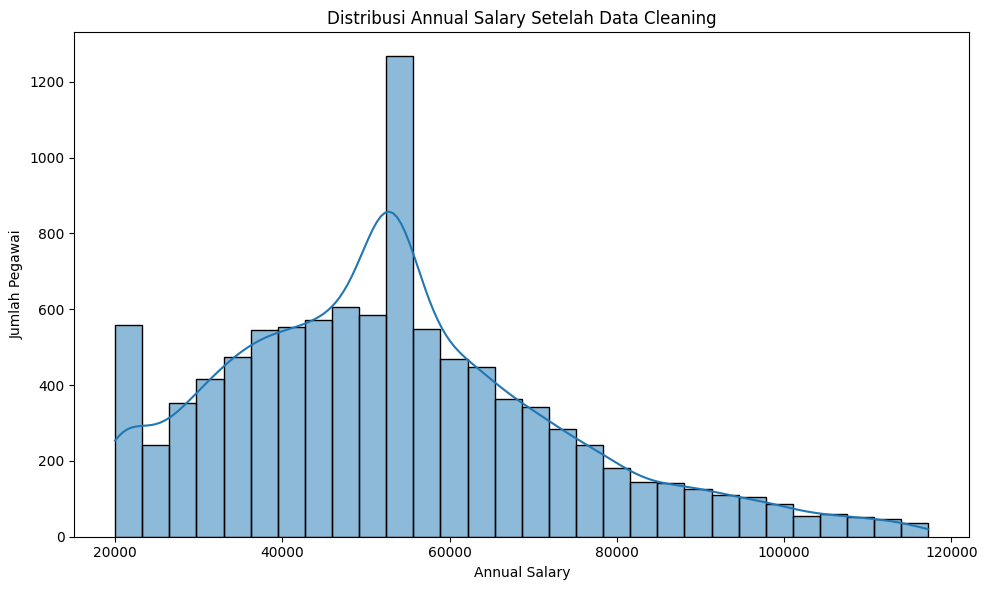

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Annual_Salary',
    bins=30,
    kde=True
)

plt.title('Distribusi Annual Salary Setelah Data Cleaning')
plt.xlabel('Annual Salary')
plt.ylabel('Jumlah Pegawai')

plt.tight_layout()
plt.show()

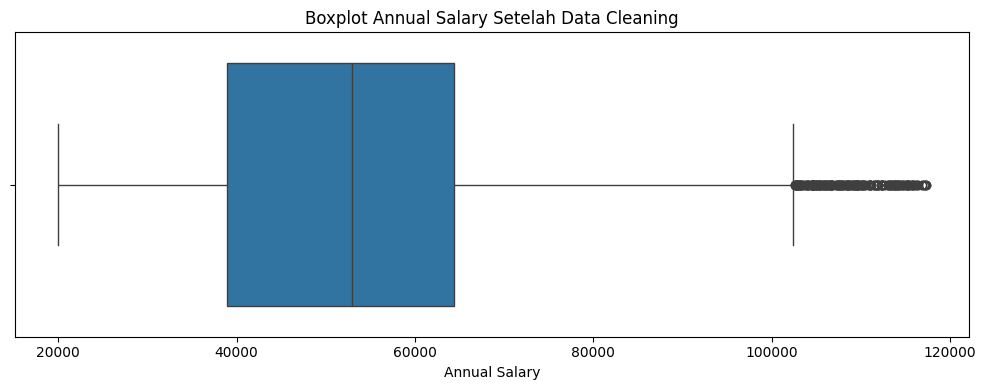

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x='Annual_Salary'
)

plt.title('Boxplot Annual Salary Setelah Data Cleaning')
plt.xlabel('Annual Salary')

plt.tight_layout()
plt.show()

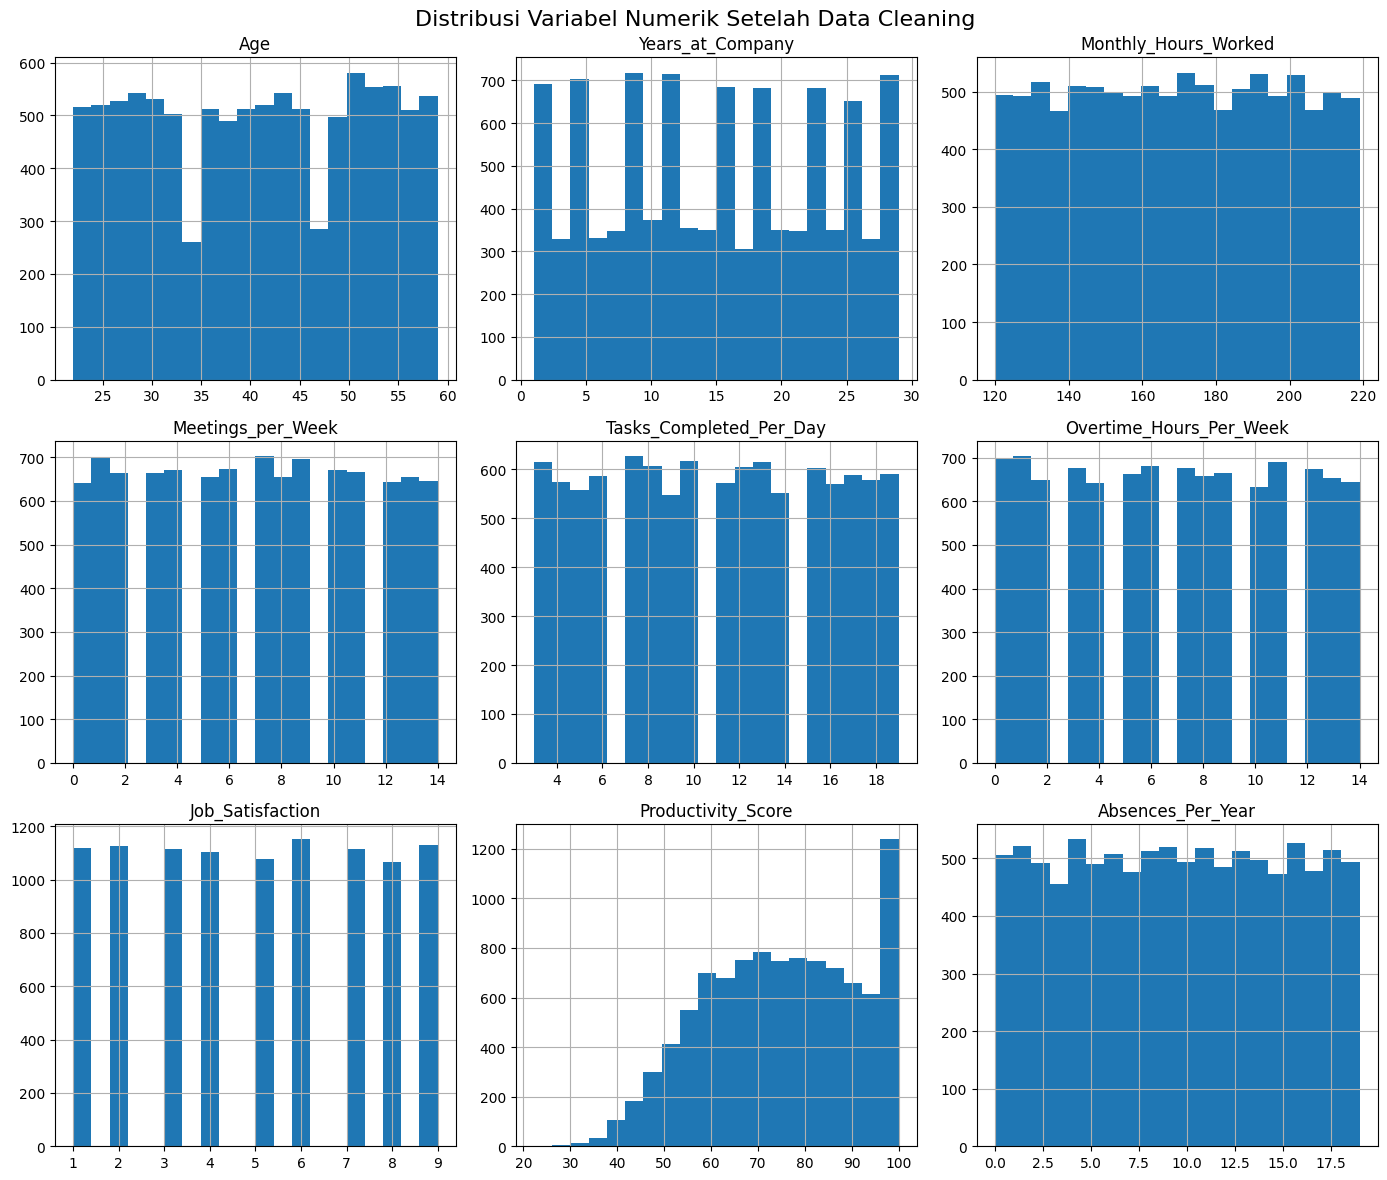

In [ ]:
numeric_for_distribution = [
    'Age',
    'Years_at_Company',
    'Monthly_Hours_Worked',
    'Meetings_per_Week',
    'Tasks_Completed_Per_Day',
    'Overtime_Hours_Per_Week',
    'Job_Satisfaction',
    'Productivity_Score',
    'Absences_Per_Year'
]

df[numeric_for_distribution].hist(
    figsize=(14, 12),
    bins=20
)

plt.suptitle(
    'Distribusi Variabel Numerik Setelah Data Cleaning',
    fontsize=16
)

plt.tight_layout()
plt.show()

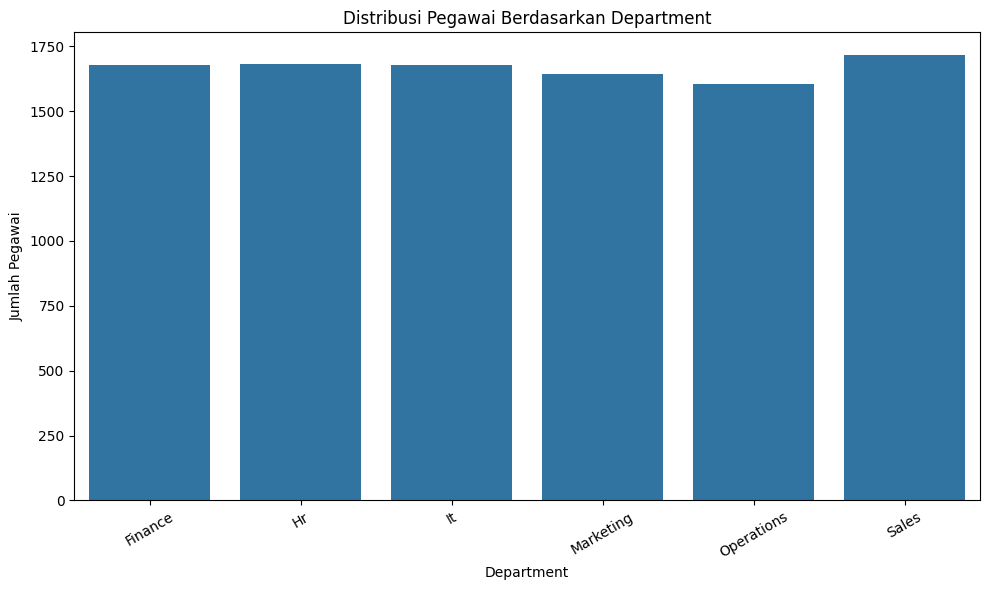

In [ ]:
department_counts = df['Department'].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=department_counts.index,
    y=department_counts.values
)

plt.title('Distribusi Pegawai Berdasarkan Department')
plt.xlabel('Department')
plt.ylabel('Jumlah Pegawai')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

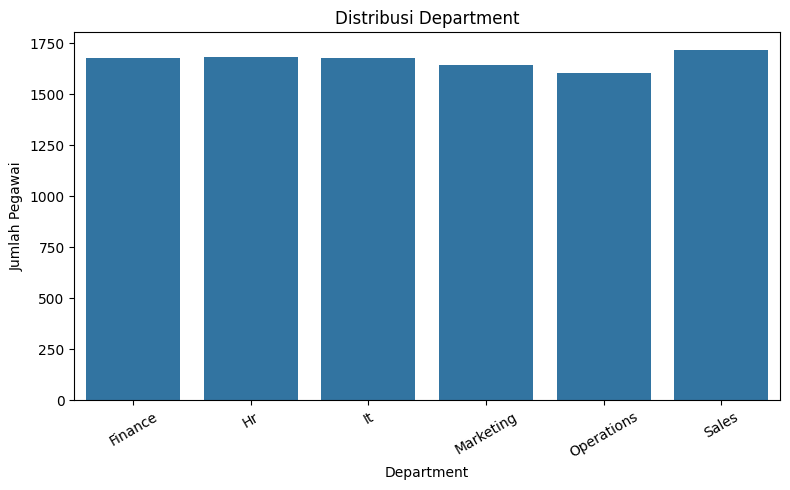

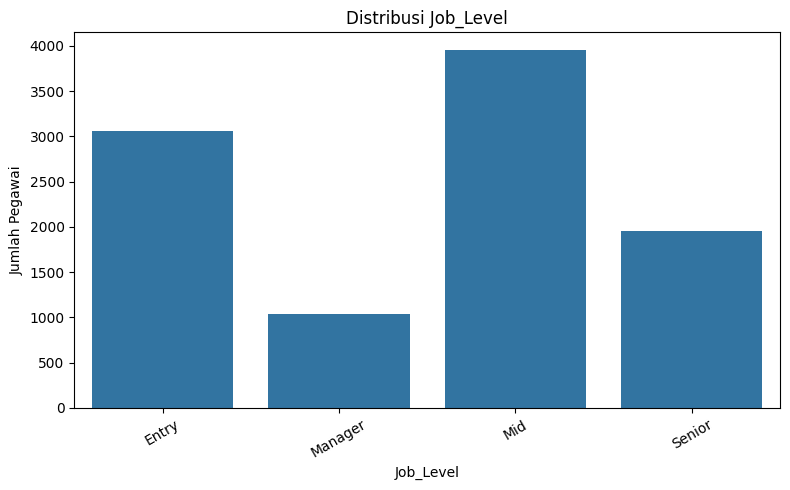

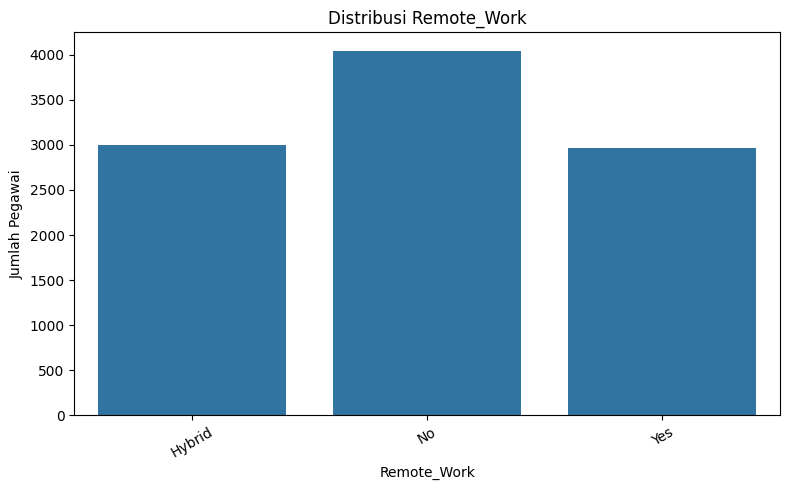

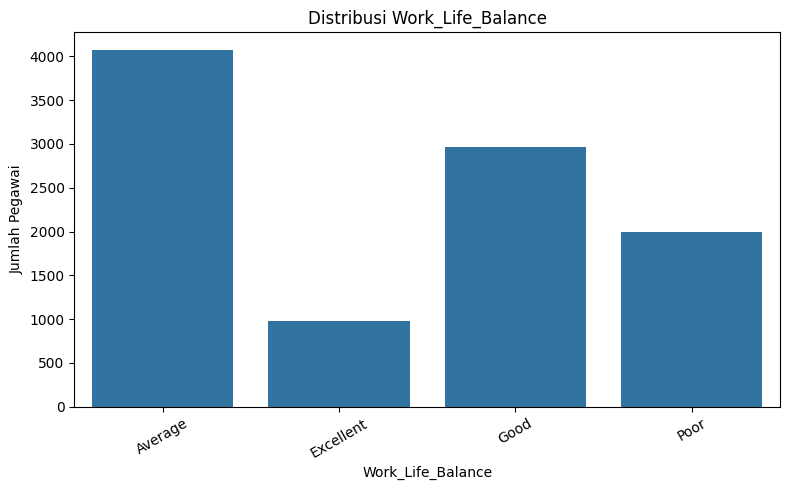

In [ ]:
for col in categorical_cols:

    plt.figure(figsize=(8, 5))

    counts = df[col].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values
    )

    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Jumlah Pegawai')

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

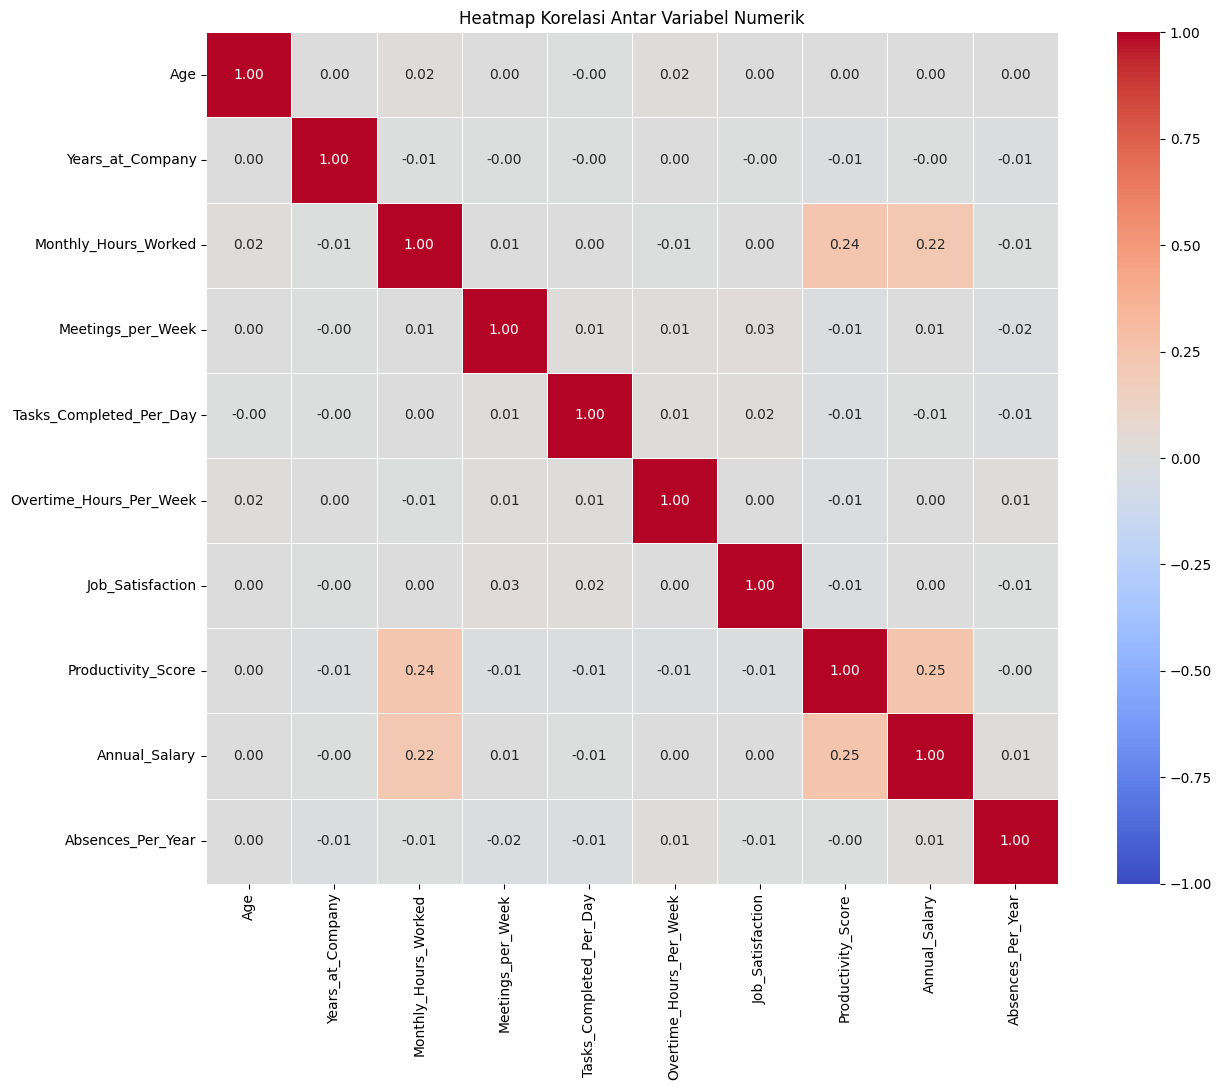

In [ ]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title(
    'Heatmap Korelasi Antar Variabel Numerik'
)

plt.tight_layout()
plt.show()

In [ ]:
focus_vars = [
    'Monthly_Hours_Worked',
    'Productivity_Score',
    'Years_at_Company'
]

salary_correlation = (
    df[focus_vars + ['Annual_Salary']]
    .corr()['Annual_Salary']
    .drop('Annual_Salary')
    .sort_values(ascending=False)
)

print("=== KORELASI DENGAN ANNUAL SALARY ===")

display(
    salary_correlation.to_frame(
        name='Correlation with Annual Salary'
    )
)

=== KORELASI DENGAN ANNUAL SALARY ===


,Correlation with Annual Salary
Productivity_Score,0.251036
Monthly_Hours_Worked,0.224971
Years_at_Company,-0.002490


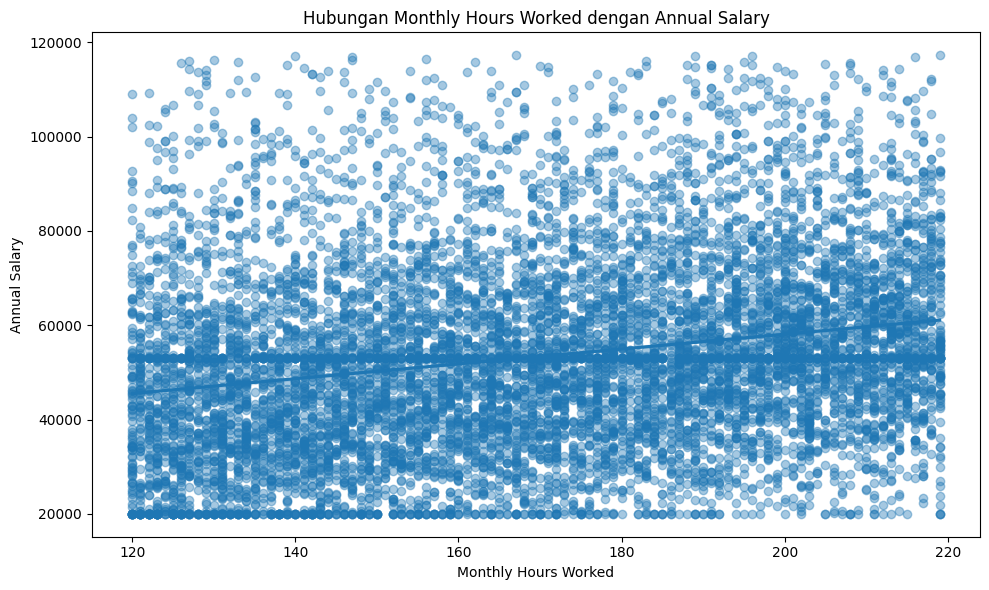

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Monthly_Hours_Worked',
    y='Annual_Salary',
    scatter_kws={'alpha': 0.4}
)

plt.title(
    'Hubungan Monthly Hours Worked dengan Annual Salary'
)

plt.xlabel('Monthly Hours Worked')
plt.ylabel('Annual Salary')

plt.tight_layout()
plt.show()

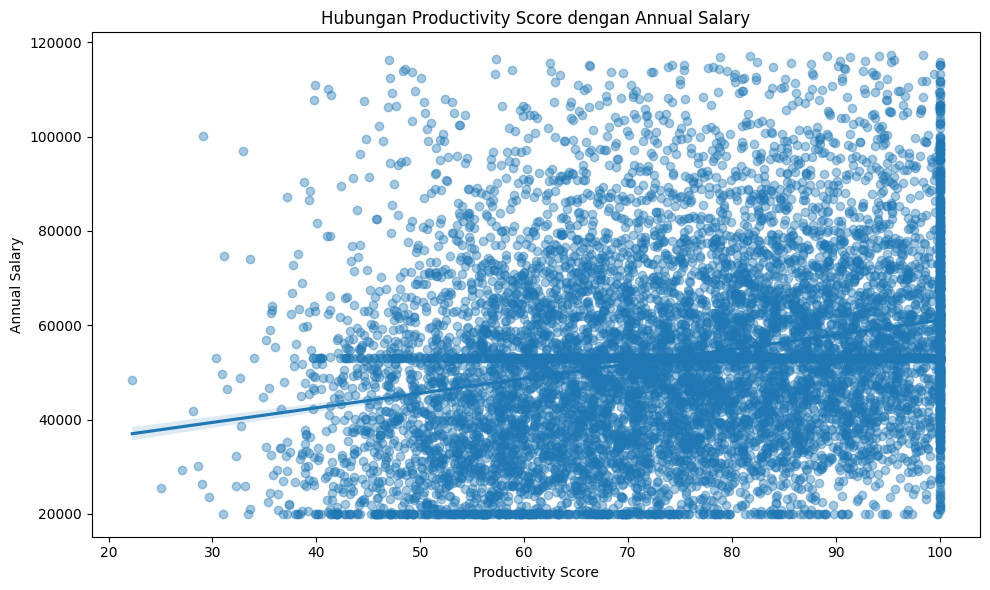

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Productivity_Score',
    y='Annual_Salary',
    scatter_kws={'alpha': 0.4}
)

plt.title(
    'Hubungan Productivity Score dengan Annual Salary'
)

plt.xlabel('Productivity Score')
plt.ylabel('Annual Salary')

plt.tight_layout()
plt.show()

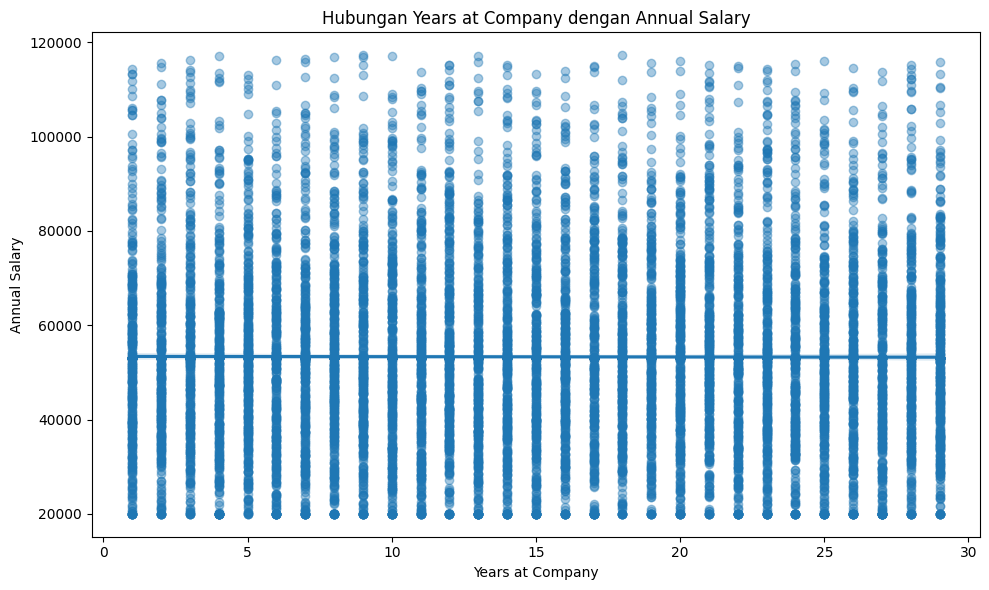

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Years_at_Company',
    y='Annual_Salary',
    scatter_kws={'alpha': 0.4}
)

plt.title(
    'Hubungan Years at Company dengan Annual Salary'
)

plt.xlabel('Years at Company')
plt.ylabel('Annual Salary')

plt.tight_layout()
plt.show()

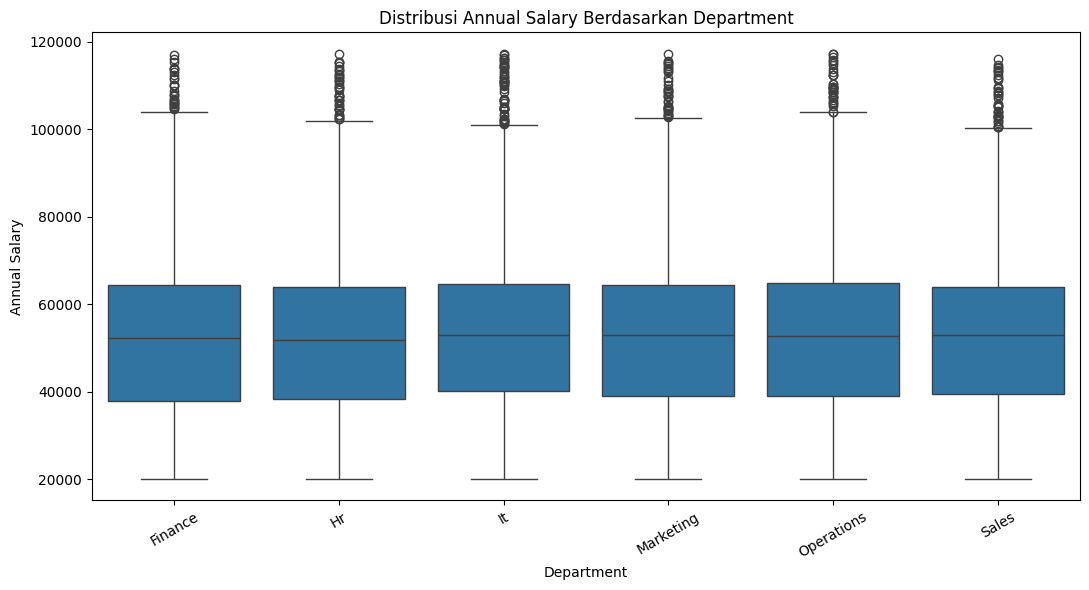

In [ ]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x='Department',
    y='Annual_Salary'
)

plt.title(
    'Distribusi Annual Salary Berdasarkan Department'
)

plt.xlabel('Department')
plt.ylabel('Annual Salary')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
df['Years_at_Company_Clean'] = (
    df['Years_at_Company']
    .astype('string')
    .str.extract(r'(\d+(?:\.\d+)?)')[0]
    .astype(float)
)

print("=== HASIL PEMBERSIHAN YEARS_AT_COMPANY ===")
display(
    df[['Years_at_Company', 'Years_at_Company_Clean']]
    .head(10)
)

=== HASIL PEMBERSIHAN YEARS_AT_COMPANY ===


,Years_at_Company,Years_at_Company_Clean
0,29 tahun,29.0
1,7 tahun,7.0
2,8 tahun,8.0
3,4 tahun,4.0
4,5 tahun,5.0
5,17 tahun,17.0
6,6 tahun,6.0
7,29 tahun,29.0
8,29 tahun,29.0
9,28 tahun,28.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10505 entries, 0 to 10504
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              10505 non-null  int64  
 1   Age                      10505 non-null  int64  
 2   Department               10502 non-null  object 
 3   Job_Level                10505 non-null  object 
 4   Years_at_Company         10505 non-null  object 
 5   Monthly_Hours_Worked     10501 non-null  float64
 6   Remote_Work              10505 non-null  object 
 7   Meetings_per_Week        10505 non-null  int64  
 8   Tasks_Completed_Per_Day  10505 non-null  int64  
 9   Overtime_Hours_Per_Week  10505 non-null  int64  
 10  Work_Life_Balance        10505 non-null  object 
 11  Job_Satisfaction         10505 non-null  int64  
 12  Productivity_Score       10505 non-null  float64
 13  Annual_Salary            10505 non-null  float64
 14  Absences_Per_Year     

In [ ]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Department,3
Job_Level,0
Years_at_Company,0
Monthly_Hours_Worked,4
Remote_Work,0
Meetings_per_Week,0
Tasks_Completed_Per_Day,0
Overtime_Hours_Per_Week,0


In [ ]:
df_cleaned = df.dropna(subset=['Department', 'Monthly_Hours_Worked'])

# ATAU

# 2. Mengisi nilai kosong (Imputasi)
# Untuk kolom kategorikal (Department), diisi dengan modus (nilai yang paling sering muncul)
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])

# Untuk kolom numerik (Monthly_Hours_Worked), diisi dengan median atau mean
df['Monthly_Hours_Worked'] = df['Monthly_Hours_Worked'].fillna(df['Monthly_Hours_Worked'].median())

# Cek kembali untuk memastikan sudah tidak ada yang kosong
print(df.isnull().sum())

Employee_ID                0
Age                        0
Department                 0
Job_Level                  0
Years_at_Company           0
Monthly_Hours_Worked       0
Remote_Work                0
Meetings_per_Week          0
Tasks_Completed_Per_Day    0
Overtime_Hours_Per_Week    0
Work_Life_Balance          0
Job_Satisfaction           0
Productivity_Score         0
Annual_Salary              0
Absences_Per_Year          0
Office_Branch              0
Years_at_Company_Clean     0
dtype: int64
